# ELT Data Pipeline: Airbyte, Snowflake, and dbt

A small end-to-end ELT (Extract-Load-Transform) pipeline. Data is extracted from a Google Sheets survey and local CSV files using **Airbyte**, loaded into a **Snowflake** data warehouse, and transformed with **dbt** into staging and mart models. The project also pulls in a public stock/FX pricing dataset from the Snowflake Marketplace and joins it against a small trading-books dataset to build a fact table with profit analysis.

The dbt project files (models, macros, config) live in the [`dbt/`](./dbt) folder alongside this notebook.


## Environment setup

- **Airbyte** (cloud, free trial) — used to extract/load data from a Google Sheets source and from local CSV files into Snowflake.
- **Snowflake** (free trial) — the destination data warehouse.
- **dbt** — installed via Miniconda, used to transform the raw loaded tables into clean staging and mart models.

Both Airbyte and Snowflake accounts were free trials created for this project; the screenshots normally required as course proof-of-work (workspace/account settings, connector configuration, data previews) are omitted here since they show account-identifying details and don't add anything for a portfolio piece.


In [ ]:
!which dbt

/home/<username>/miniconda3/envs/p4-env/bin/dbt


## Snowflake configuration

Set up the warehouse, databases, a dedicated role, and schemas via a few SQL transactions run directly in the Snowflake worksheet:


In [ ]:
# ---------------- Transaction 1 ----------------
# USE ROLE ACCOUNTADMIN;

# CREATE WAREHOUSE IF NOT EXISTS P4_WAREHOUSE
# WAREHOUSE_SIZE = XSMALL
# AUTO_SUSPEND = 3600
# AUTO_RESUME = TRUE
# INITIALLY_SUSPENDED = TRUE;

# CREATE DATABASE IF NOT EXISTS SURVEY_DATABASE;
# CREATE DATABASE IF NOT EXISTS STOCK_DB;

# ---------------- Transaction 2 ----------------
# CREATE ROLE IF NOT EXISTS P4_ROLE;

# GRANT ROLE P4_ROLE TO ROLE SYSADMIN;

# GRANT USAGE ON WAREHOUSE P4_WAREHOUSE TO ROLE P4_ROLE;

# GRANT ROLE P4_ROLE TO USER <your_username>;

# GRANT OWNERSHIP ON DATABASE SURVEY_DATABASE TO ROLE P4_ROLE;
# GRANT OWNERSHIP ON DATABASE STOCK_DB TO ROLE P4_ROLE;

# USE ROLE P4_ROLE;

# ---------------- Transaction 3 ----------------
# CREATE SCHEMA IF NOT EXISTS SURVEY_DATABASE.SURVEY_SCHEMA;
# CREATE SCHEMA IF NOT EXISTS STOCK_DB.STOCK_SCHEMA;

# GRANT OWNERSHIP ON SCHEMA SURVEY_DATABASE.SURVEY_SCHEMA TO ROLE P4_ROLE;
# GRANT OWNERSHIP ON SCHEMA STOCK_DB.STOCK_SCHEMA TO ROLE P4_ROLE;

## Loading data with Airbyte

Two Airbyte connections were configured:
- A **Google Sheets** source (a short class survey) → Snowflake, landing in `SURVEY_DATABASE.SURVEY_SCHEMA.SURVEY`.
- A **local CSV** source (`trading_books.csv` and `weights_table.csv`, a small synthetic trading dataset) → Snowflake, landing in `STOCK_DB.STOCK_SCHEMA` as `TRADING_BOOKS` and `WEIGHTS_TABLE`.

(Setup screenshots omitted — see note above.)


## dbt: cleaning up the survey column names

The survey's raw column names (verbatim Google Form question text) are transformed into clean snake_case names with a dbt staging model, `transform_survey.sql`, producing a view called `transform_survey`.

`~/.dbt/profiles.yml` holds the Snowflake connection profile; the password lives outside the notebook and the account/user fields below are redacted since they're specific to my trial account:


In [ ]:
!cat ~/.dbt/profiles.yml | grep -v password

p4_data_pipeline:
  outputs:
    dev:
      account: <account_locator>
      database: SURVEY_DATABASE
      role: ACCOUNTADMIN
      schema: SURVEY_SCHEMA
      threads: 1
      type: snowflake
      user: <your_username>
      warehouse: P4_WAREHOUSE
  target: dev


In [6]:
!cat ../models/schema.yml

version: 2

sources:
  - name: airbyte_survey_data
    database: SURVEY_DATABASE
    schema: SURVEY_SCHEMA
    tables:
      - name: survey



In [7]:
!cat ../models/staging/transform_survey.sql

select
    timestamp,
    "EMAIL ADDRESS" as email_address,
    "WHAT IS YOUR AGE?" as age,
    "DO YOU OWN A VR HEADSET?" as own_vr_headset,
    "DO YOU PREFER CATS OR DOGS?" as prefer_cats_or_dogs,
    "WHAT IS YOUR CURRENT STANDING?" as current_standing,
    "WHAT IS YOUR FAVORITE TV SHOW?" as favorite_tv_show,
    "WHEN DO YOU PREFER TO TAKE EXAMS?" as preferred_exam_time,
    "  WHAT IS YOUR PREFERRED BEVERAGE?  " as preferred_beverage,
    "WHAT IS YOUR FAVORITE ICE CREAM FLAVOR?" as favorite_ice_cream_flavor,
    "  WHAT IS YOUR FAVORITE SEASON OF THE YEAR?  " as favorite_season,
    "WHAT IS YOUR FAVORITE OR PREFERRED LLM TO USE?" as preferred_llm,
    "WHAT FACTOR INFLUENCES YOUR COURSE SELECTION THE MOST?" as course_selection_factor,
    "WOULD YOU DESCRIBE YOURSELF AS AN ""EARLY BIRD"" OR A ""NIGHT OWL""?" as early_bird_or_night_owl,
    "IF YOU HAVE SECONDARY MAJORS, PLEASE LIST THEM HERE, SEPARATED BY A COMMA." as secondary_majors,
    "
WHICH BEST DESCRIBES YOUR PRIMARY M

## Survey data analysis

A few exploratory questions against the cleaned `transform_survey` view.


### What's the distribution of preferred beverage?

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

query = """
SELECT 
    preferred_beverage,
    COUNT(*) AS count
FROM TRANSFORM_SURVEY
GROUP BY preferred_beverage
ORDER BY count DESC
"""

cur.execute(query)
rows = cur.fetchall()

beverage_counts = pd.DataFrame(rows, columns=[desc[0] for desc in cur.description])
beverage_counts

,PREFERRED_BEVERAGE,COUNT
0,Water,45
1,Coffee,30
2,Soda,18
3,Tea,11
4,Juice,9
5,Energy Drinks,8
6,Other,6


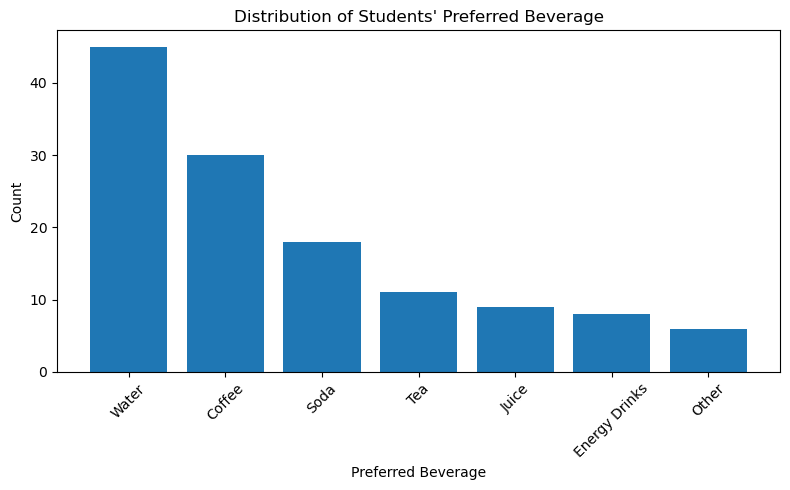

In [19]:
plt.figure(figsize=(8, 5))
plt.bar(beverage_counts["PREFERRED_BEVERAGE"], beverage_counts["COUNT"])
plt.xticks(rotation=45)
plt.xlabel("Preferred Beverage")
plt.ylabel("Count")
plt.title("Distribution of Students' Preferred Beverage")
plt.tight_layout()
plt.show()

### Do students prefer cats or dogs?

In [23]:
query = """
SELECT 
    PREFER_CATS_OR_DOGS,
    COUNT(*) AS count
FROM TRANSFORM_SURVEY
GROUP BY PREFER_CATS_OR_DOGS
ORDER BY count DESC
"""

cur.execute(query)
rows = cur.fetchall()

import pandas as pd
cats_dogs_counts = pd.DataFrame(rows, columns=[desc[0] for desc in cur.description])
cats_dogs_counts

,PREFER_CATS_OR_DOGS,COUNT
0,Dogs,84
1,Cats,36
2,Neither,7


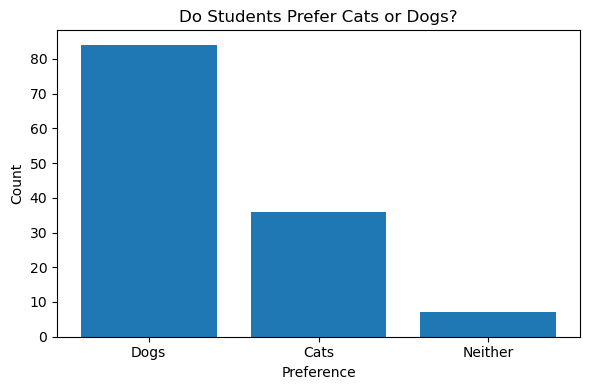

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.bar(cats_dogs_counts["PREFER_CATS_OR_DOGS"], cats_dogs_counts["COUNT"])
plt.xlabel("Preference")
plt.ylabel("Count")
plt.title("Do Students Prefer Cats or Dogs?")
plt.tight_layout()
plt.show()

### What's the distribution of current standing?

In [27]:
query = """
SELECT 
    CURRENT_STANDING,
    COUNT(*) AS count
FROM TRANSFORM_SURVEY
GROUP BY CURRENT_STANDING
ORDER BY count DESC
"""

cur.execute(query)
rows = cur.fetchall()

import pandas as pd
standing_counts = pd.DataFrame(rows, columns=[desc[0] for desc in cur.description])
standing_counts

,CURRENT_STANDING,COUNT
0,Senior (or above),66
1,Junior,35
2,Sophomore,16
3,Graduate Student,10


### What are the most popular ice cream flavors?

In [31]:
query = """
SELECT 
    FAVORITE_ICE_CREAM_FLAVOR,
    COUNT(*) AS count
FROM TRANSFORM_SURVEY
GROUP BY FAVORITE_ICE_CREAM_FLAVOR
ORDER BY count DESC
"""

cur.execute(query)
rows = cur.fetchall()

import pandas as pd
ice_cream_counts = pd.DataFrame(rows, columns=[desc[0] for desc in cur.description])
ice_cream_counts

,FAVORITE_ICE_CREAM_FLAVOR,COUNT
0,Cookies & Cream,33
1,Chocolate,23
2,Mint Chocolate Chip,22
3,Vanilla,16
4,Other,12
5,Strawberry,11
6,Rocky Road,6
7,Caramel Swirl,4


### What's the distribution of favorite seasons?

In [34]:
query = """
SELECT 
    FAVORITE_SEASON,
    COUNT(*) AS count
FROM TRANSFORM_SURVEY
WHERE FAVORITE_SEASON IS NOT NULL
GROUP BY FAVORITE_SEASON
ORDER BY count DESC
"""

cur.execute(query)
rows = cur.fetchall()

import pandas as pd
season_counts = pd.DataFrame(rows, columns=[desc[0] for desc in cur.description])
season_counts

,FAVORITE_SEASON,COUNT
0,Summer,50
1,Spring,34
2,Fall,32
3,Winter,11


### Is there a relationship between owning a VR headset and preferred LLM?

In [38]:
query = """
SELECT 
    OWN_VR_HEADSET,
    PREFERRED_LLM,
    COUNT(*) AS count
FROM TRANSFORM_SURVEY
WHERE OWN_VR_HEADSET IS NOT NULL
  AND PREFERRED_LLM IS NOT NULL
GROUP BY OWN_VR_HEADSET, PREFERRED_LLM
ORDER BY OWN_VR_HEADSET, count DESC
"""

cur.execute(query)
rows = cur.fetchall()

import pandas as pd
vr_llm_counts = pd.DataFrame(rows, columns=[desc[0] for desc in cur.description])
vr_llm_counts

,OWN_VR_HEADSET,PREFERRED_LLM,COUNT
0,No,Claude,50
1,No,ChatGPT,38
2,No,Gemini,16
3,No,I do not like using AI,1
4,No,Copilot,1
5,Yes,Claude,11
6,Yes,ChatGPT,8
7,Yes,Gemini,1
8,Yes,Grok,1


In [40]:
vr_llm_pivot = vr_llm_counts.pivot(
    index="OWN_VR_HEADSET",
    columns="PREFERRED_LLM",
    values="COUNT"
).fillna(0)

vr_llm_pivot

PREFERRED_LLM,ChatGPT,Claude,Copilot,Gemini,Grok,I do not like using AI
OWN_VR_HEADSET,,,,,,
No,38.0,50.0,1.0,16.0,0.0,1.0
Yes,8.0,11.0,0.0,1.0,1.0,0.0


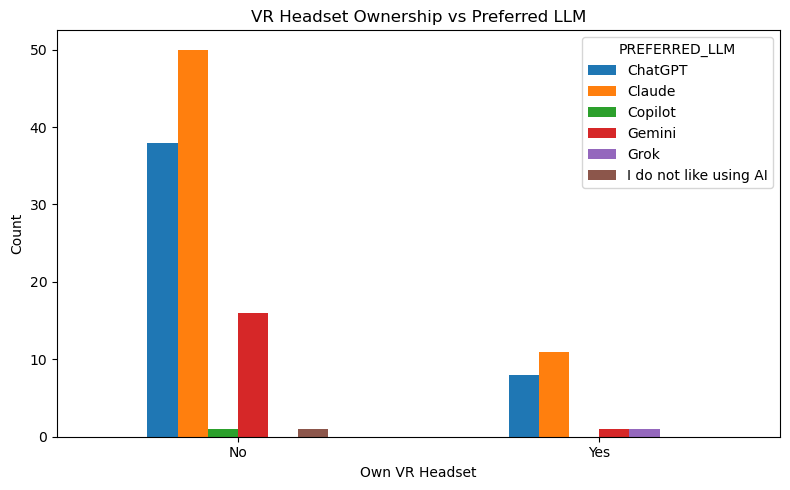

In [42]:
import matplotlib.pyplot as plt

vr_llm_pivot.plot(kind="bar", figsize=(8, 5))

plt.title("VR Headset Ownership vs Preferred LLM")
plt.xlabel("Own VR Headset")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Is there a relationship between major and being an early bird vs night owl?

In [45]:
query = """
SELECT 
    PRIMARY_MAJOR,
    COUNT(*) AS count
FROM TRANSFORM_SURVEY
WHERE PRIMARY_MAJOR IS NOT NULL
GROUP BY PRIMARY_MAJOR
ORDER BY count DESC
LIMIT 5
"""

cur.execute(query)
top_majors = [row[0] for row in cur.fetchall()]

top_majors

['Computer Science', 'Data Science', 'Other', 'Engineering (Any kind)']

In [47]:
query = f"""
SELECT 
    PRIMARY_MAJOR,
    EARLY_BIRD_OR_NIGHT_OWL,
    COUNT(*) AS count
FROM TRANSFORM_SURVEY
WHERE PRIMARY_MAJOR IN ({','.join([f"'{m}'" for m in top_majors])})
  AND EARLY_BIRD_OR_NIGHT_OWL IS NOT NULL
GROUP BY PRIMARY_MAJOR, EARLY_BIRD_OR_NIGHT_OWL
ORDER BY PRIMARY_MAJOR, count DESC
"""

cur.execute(query)
rows = cur.fetchall()

import pandas as pd
major_schedule_counts = pd.DataFrame(rows, columns=[desc[0] for desc in cur.description])
major_schedule_counts

,PRIMARY_MAJOR,EARLY_BIRD_OR_NIGHT_OWL,COUNT
0,Computer Science,Night Owl,41
1,Computer Science,Early Bird,13
2,Computer Science,Neither,12
3,Data Science,Night Owl,34
4,Data Science,Early Bird,14
5,Data Science,Neither,6
6,Engineering (Any kind),Early Bird,2
7,Engineering (Any kind),Night Owl,1
8,Other,Night Owl,4


In [49]:
major_schedule_pivot = major_schedule_counts.pivot(
    index="PRIMARY_MAJOR",
    columns="EARLY_BIRD_OR_NIGHT_OWL",
    values="COUNT"
).fillna(0)

major_schedule_pivot

EARLY_BIRD_OR_NIGHT_OWL,Early Bird,Neither,Night Owl
PRIMARY_MAJOR,,,
Computer Science,13.0,12.0,41.0
Data Science,14.0,6.0,34.0
Engineering (Any kind),2.0,0.0,1.0
Other,0.0,0.0,4.0


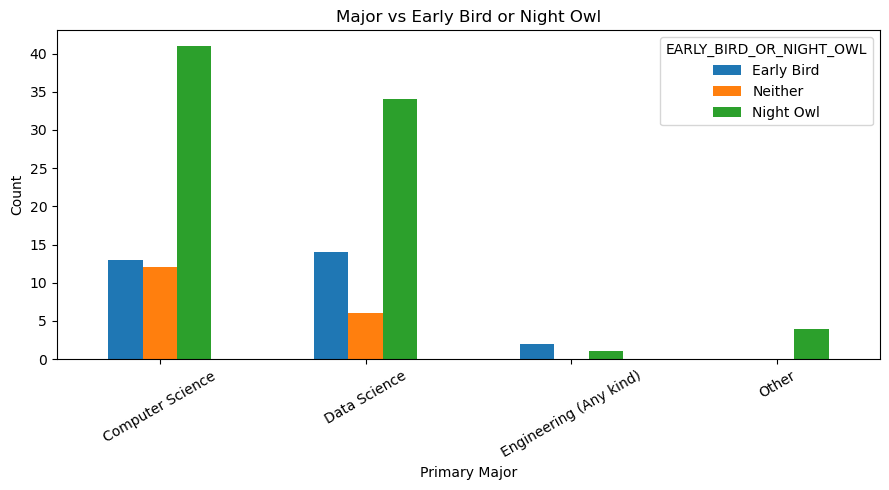

In [51]:
import matplotlib.pyplot as plt

major_schedule_pivot.plot(kind="bar", figsize=(9, 5))

plt.title("Major vs Early Bird or Night Owl")
plt.xlabel("Primary Major")
plt.ylabel("Count")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Stock and FX dataset analysis

Beyond the survey and trading-books data, this section pulls in a public stock/FX pricing dataset from the **Snowflake Marketplace** (`Snowflake Public Data (Free)`, specifically the `STOCK_PRICE_TIMESERIES_PIT` and `FX_RATES_TIMESERIES_PIT` views) and joins it against the trading books to build a small fact table.

(Marketplace setup screenshots omitted.)


In [ ]:
cat ~/.dbt/profiles.yml | grep -v password

p4_data_pipeline:
  target: dev
  outputs:
    dev:
      type: snowflake
      account: <account_locator>
      user: <your_username>
      role: ACCOUNTADMIN
      database: SURVEY_DATABASE
      warehouse: P4_WAREHOUSE
      schema: SURVEY_SCHEMA
      threads: 1

    stock_db:
      type: snowflake
      account: <account_locator>
      user: <your_username>
      role: ACCOUNTADMIN
      database: STOCK_DB
      warehouse: P4_WAREHOUSE
      schema: STOCK_SCHEMA
      threads: 1


In [14]:
!cat models/schema.yml

version: 2

sources:
  - name: airbyte_survey_data
    database: SURVEY_DATABASE
    schema: SURVEY_SCHEMA
    tables:
      - name: survey

  - name: snowflake_public_data
    database: SNOWFLAKE_PUBLIC_DATA_FREE
    schema: PUBLIC_DATA_FREE
    tables:
      - name: STOCK_PRICE_TIMESERIES_PIT
      - name: FX_RATES_TIMESERIES_PIT

  - name: airbyte_csv_data
    database: STOCK_DB
    schema: STOCK_SCHEMA
    tables:
      - name: TRADING_BOOKS
      - name: WEIGHTS_TABLE


In [15]:
!cat ~/p4_data_pipeline/dbt_project.yml

name: 'p4_data_pipeline'
version: '1.0.0'
config-version: 2

profile: 'p4_data_pipeline'

model-paths: ["models"]
analysis-paths: ["analyses"]
test-paths: ["tests"]
seed-paths: ["seeds"]
macro-paths: ["macros"]
snapshot-paths: ["snapshots"]

clean-targets:
  - "target"
  - "dbt_packages"

models:
  p4_data_pipeline:
    staging:
      +materialized: view
      +snowflake_warehouse: P4_WAREHOUSE
    marts:
      +materialized: table
      +snowflake_warehouse: P4_WAREHOUSE


### Staging models: valid tickers and joined pricing info

In [18]:
!cat ~/p4_data_pipeline/models/staging/staging_valid_fx_tickers.sql

select distinct
    TICKER,
    TRADE_DATE
from {{ source('airbyte_csv_data', 'TRADING_BOOKS') }}
where DESK = 'FX Desk'


In [28]:
query = """
SELECT *
FROM STOCK_DB.STOCK_SCHEMA.staging_valid_fx_tickers
ORDER BY trade_date, ticker
"""

cur.execute(query)
results = cur.fetchall()

import pandas as pd
pd.DataFrame(results)

,0,1
0,EUR/USD,2024-03-01
1,GBP/USD,2024-03-01
2,EUR/USD,2024-03-04
3,GBP/USD,2024-03-04
4,EUR/USD,2024-03-05
5,GBP/USD,2024-03-05


In [19]:
!cat ~/p4_data_pipeline/models/staging/staging_valid_stock_tickers.sql

select distinct
    TICKER,
    TRADE_DATE
from {{ source('airbyte_csv_data', 'TRADING_BOOKS') }}
where DESK = 'Equity Desk'


In [29]:
query = """
SELECT *
FROM STOCK_DB.STOCK_SCHEMA.staging_valid_stock_tickers
ORDER BY trade_date, ticker
"""

cur.execute(query)
pd.DataFrame(cur.fetchall())

,0,1
0,AAPL,2024-03-01
1,GOOGL,2024-03-01
2,MSFT,2024-03-01
3,AAPL,2024-03-04
4,GOOGL,2024-03-04
5,MSFT,2024-03-04
6,AAPL,2024-03-05
7,GOOGL,2024-03-05
8,MSFT,2024-03-05


In [20]:
!cat ~/p4_data_pipeline/models/staging/staging_valid_fx_info.sql

select
    f.TICKER,
    f.TRADE_DATE,
    r.VARIABLE_NAME,
    r.VALUE as EXCHANGE_RATE
from {{ ref('staging_valid_fx_tickers') }} f
join {{ source('snowflake_public_data', 'FX_RATES_TIMESERIES_PIT') }} r
    on f.TRADE_DATE = r.DATE
where (r.BASE_CURRENCY_ID = 'EUR' and r.QUOTE_CURRENCY_ID = 'USD')
   or (r.BASE_CURRENCY_ID = 'GBP' and r.QUOTE_CURRENCY_ID = 'USD')


In [30]:
query = """
SELECT *
FROM STOCK_DB.STOCK_SCHEMA.staging_valid_fx_info
ORDER BY trade_date, ticker, variable_name
"""

cur.execute(query)
pd.DataFrame(cur.fetchall())

,0,1,2,3
0,EUR/USD,2024-03-01,EUR/USD Exchange Rate,1.0813
1,EUR/USD,2024-03-01,EUR/USD Exchange Rate,1.0813
2,EUR/USD,2024-03-01,GBP/USD Exchange Rate,1.2634
3,EUR/USD,2024-03-01,GBP/USD Exchange Rate,1.2634
4,GBP/USD,2024-03-01,EUR/USD Exchange Rate,1.0813
5,GBP/USD,2024-03-01,EUR/USD Exchange Rate,1.0813
6,GBP/USD,2024-03-01,GBP/USD Exchange Rate,1.2634
7,GBP/USD,2024-03-01,GBP/USD Exchange Rate,1.2634
8,EUR/USD,2024-03-04,EUR/USD Exchange Rate,1.0846
9,EUR/USD,2024-03-04,EUR/USD Exchange Rate,1.0846


In [34]:
!cat ~/p4_data_pipeline/models/staging/staging_valid_stock_info.sql

select
    s.TICKER,
    s.TRADE_DATE,
    p.VARIABLE,
    p.VALUE
from {{ ref('staging_valid_stock_tickers') }} s
join {{ source('snowflake_public_data', 'STOCK_PRICE_TIMESERIES_PIT') }} p
    on s.TICKER = p.TICKER
   and TO_DATE(s.TRADE_DATE) = TO_DATE(p.DATE)
where p.VARIABLE in ('all_day_high', 'all_day_low')


In [35]:
query = """
SELECT *
FROM STOCK_DB.STOCK_SCHEMA.staging_valid_stock_info
ORDER BY trade_date, ticker, variable
"""

cur.execute(query)

rows = cur.fetchall()
columns = [desc[0] for desc in cur.description]

pd.DataFrame(rows, columns=columns)

,TICKER,TRADE_DATE,VARIABLE,VALUE


### Joining buy/sell trade pairs

Each trade appears in `TRADING_BOOKS` as a separate `BUY` and `SELL` row for the same trader/day; this staging view joins them into one row per trade.


In [49]:
!cat ~/p4_data_pipeline/models/staging/staging_buy_sell_joint.sql

{{ config(materialized='view') }}

select
    b.trade_id as trade_id,
    b.trade_date as trade_date,
    b.trader_name as trader_name,
    b.desk as desk,
    b.ticker as ticker,
    b.quantity as quantity_buy,
    b.price as price_buy,
    s.quantity as quantity_sell,
    s.price as price_sell
from {{ source('airbyte_csv_data', 'TRADING_BOOKS') }} b
join {{ source('airbyte_csv_data', 'TRADING_BOOKS') }} s
    on b.trader_name = s.trader_name
   and b.trade_date = s.trade_date
where b.trade_type = 'BUY'
  and s.trade_type = 'SELL'
order by b.trade_id


In [56]:
query = """
SELECT *
FROM STOCK_DB.STOCK_SCHEMA.staging_buy_sell_joint
ORDER BY trade_id
"""
cur.execute(query)
cur.fetch_pandas_all()

,TRADE_ID,TRADE_DATE,TRADER_NAME,DESK,TICKER,QUANTITY_BUY,PRICE_BUY,QUANTITY_SELL,PRICE_SELL
0,1001.0,2024-03-01,John Smith,Equity Desk,AAPL,100.0,175.500,100.0,178.250
1,1003.0,2024-03-01,Sarah Johnson,FX Desk,EUR/USD,100000.0,1.085,100000.0,1.092
2,1005.0,2024-03-01,Michael Chen,Equity Desk,MSFT,50.0,405.750,50.0,408.500
3,1007.0,2024-03-01,Lisa Wong,FX Desk,GBP/USD,75000.0,1.265,75000.0,1.272
4,1009.0,2024-03-01,David Kim,Equity Desk,GOOGL,75.0,141.250,75.0,142.500
5,1011.0,2024-03-04,John Smith,Equity Desk,AAPL,150.0,176.250,150.0,179.500
6,1013.0,2024-03-04,Sarah Johnson,FX Desk,EUR/USD,125000.0,1.088,125000.0,1.095
7,1015.0,2024-03-04,Michael Chen,Equity Desk,MSFT,75.0,407.250,75.0,410.750
8,1017.0,2024-03-04,Lisa Wong,FX Desk,GBP/USD,100000.0,1.268,100000.0,1.275
9,1019.0,2024-03-04,David Kim,Equity Desk,GOOGL,100.0,142.250,100.0,144.500


### Fact table: trading profit

A mart-layer fact table computing buy money, sell money, and profit per trade.


In [54]:
!cat ~/p4_data_pipeline/models/marts/fact_tab_trading.sql

{{ config(materialized='table') }}

select
    trade_id,
    price_buy * quantity_buy as buy_money,
    price_sell * quantity_sell as sell_money,
    (price_sell * quantity_sell) - (price_buy * quantity_buy) as profit
from {{ ref('staging_buy_sell_joint') }}
order by trade_id


In [57]:
query = """
SELECT *
FROM STOCK_DB.STOCK_SCHEMA.fact_tab_trading
ORDER BY trade_id
"""
cur.execute(query)
cur.fetch_pandas_all()

,TRADE_ID,BUY_MONEY,SELL_MONEY,PROFIT
0,1001.0,17550.00,17825.00,275.00
1,1003.0,108500.00,109200.00,700.00
2,1005.0,20287.50,20425.00,137.50
3,1007.0,94875.00,95400.00,525.00
4,1009.0,10593.75,10687.50,93.75
5,1011.0,26437.50,26925.00,487.50
6,1013.0,136000.00,136875.00,875.00
7,1015.0,30543.75,30806.25,262.50
8,1017.0,126800.00,127500.00,700.00
9,1019.0,14225.00,14450.00,225.00


### Total profit by desk

In [61]:
query = """
SELECT
    DESK,
    SUM((PRICE_SELL * QUANTITY_SELL) - (PRICE_BUY * QUANTITY_BUY)) AS TOTAL_PROFIT
FROM STOCK_DB.STOCK_SCHEMA.staging_buy_sell_joint
GROUP BY DESK
ORDER BY DESK
"""
cur.execute(query)
cur.fetch_pandas_all()

,DESK,TOTAL_PROFIT
0,Equity Desk,2718.75
1,FX Desk,5000.00


### Profit rate by desk

In [62]:
query = """
SELECT
    DESK,
    (
        SUM(PRICE_SELL * QUANTITY_SELL) - SUM(PRICE_BUY * QUANTITY_BUY)
    ) 
    /
    NULLIF(SUM(PRICE_BUY * QUANTITY_BUY), 0) AS PROFIT_RATE
FROM STOCK_DB.STOCK_SCHEMA.staging_buy_sell_joint
GROUP BY DESK
ORDER BY DESK
"""
cur.execute(query)
cur.fetch_pandas_all()

,DESK,PROFIT_RATE
0,Equity Desk,0.012701
1,FX Desk,0.006342
